# Importing

In [1]:
import io
import os
import pickle
import time
import warnings
import librosa
import numpy as np
import pandas as pd
import tensorflow as tf
!pip install azure-storage-blob
!pip install seaborn python-dotenv librosa scikit-learn
from azure.storage.blob import BlobServiceClient
from dotenv import load_dotenv
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
)
import tensorflow.keras.layers as L
from audio_pipeline import extract_features_from_audio_array, get_feature_names
from config import (
    ASSETS_DIR,
    ENCODER_PATH,
    MODEL_PATH,
    MONO,
    N_FEATURES, 
    SCALER_PATH,
    TARGET_SR,
)
from manifest_builder import (
    add_augmented_rows,
    assign_splits,
    build_manifest,
    save_manifest,
    validate_manifest,
)
from speaker_splitter import add_speaker_column, speaker_split

warnings.filterwarnings("ignore")
load_dotenv()


True

# Integration with Azure

In [2]:
from azure.storage.blob import BlobServiceClient
import pandas as pd
import os
from dotenv import load_dotenv
import numpy as np
import io
import librosa


load_dotenv()

CONTAINER_NAME = "wav-files"

connection_string = os.getenv("AZURE_STORAGE_CONNECTION_STRING")

if not connection_string:
    raise ValueError("AZURE_STORAGE_CONNECTION_STRING not set")

blob_service = BlobServiceClient.from_connection_string(connection_string)
container_client = blob_service.get_container_client(CONTAINER_NAME)


def get_df_from_blob_dataset(prefix):
    emotions = []
    file_paths = []

    for blob in container_client.list_blobs(name_starts_with=prefix):
        if blob.name.endswith(".wav"):
            filename = blob.name.split("/")[-1]
            parts = filename.split("-")

            if len(parts) >= 3:
                emotion = parts[2].lower()
            else:
                emotion = "unknown"

            emotions.append(emotion)
            file_paths.append(blob.name)

    return pd.DataFrame({
        "Path": file_paths,
        "Emotions": emotions
    })


def load_audio_from_blob(blob_service, blob_path: str) -> tuple[np.ndarray, int]:
    clean_path = blob_path.replace("\\", "/")
    blob_client = blob_service.get_blob_client(container=CONTAINER_NAME, blob=clean_path)
    audio_file = io.BytesIO(blob_client.download_blob().readall())
    data, sr = librosa.load(audio_file, sr=TARGET_SR, mono=MONO)
    return data.astype(np.float32), sr



ravdess_df = get_df_from_blob_dataset("RAVDESS/")
crema_df   = get_df_from_blob_dataset("CREMAD/")
tess_df    = get_df_from_blob_dataset("TESS/")
savee_df   = get_df_from_blob_dataset("SAVEE/")

data_path = pd.concat(
    [ravdess_df, crema_df, tess_df, savee_df],
    axis=0
).reset_index(drop=True)

data_path.to_csv("data_path.csv", index=False)

print("Total files:", len(data_path))
print(data_path.head())
print("\nEmotion distribution:")
print(data_path["Emotions"].value_counts())

Total files: 7472
                                           Path Emotions
0  RAVDESS/Actor_01/RAVDESS-01-Angry-1-dup0.wav    angry
1  RAVDESS/Actor_01/RAVDESS-01-Angry-1-dup1.wav    angry
2  RAVDESS/Actor_01/RAVDESS-01-Angry-1-dup2.wav    angry
3  RAVDESS/Actor_01/RAVDESS-01-Angry-1-dup3.wav    angry
4  RAVDESS/Actor_01/RAVDESS-01-Angry-2-dup0.wav    angry

Emotion distribution:
Emotions
angry      1923
happy      1923
sad        1923
neutral    1703
Name: count, dtype: int64


# EDA

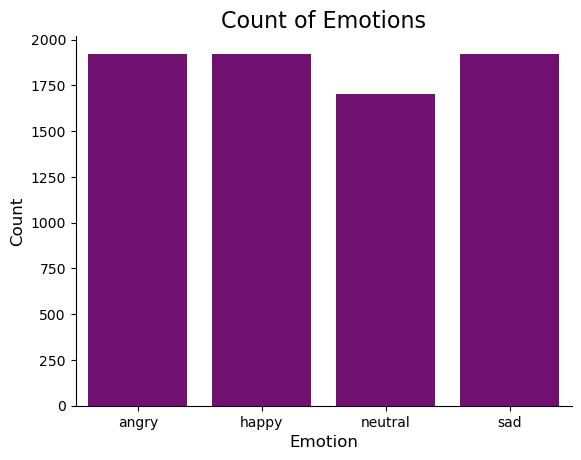

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.countplot(
    x=data_path["Emotions"],  
    color="purple"             
)
plt.title('Count of Emotions', size=16)
plt.xlabel('Emotion', size=12)
plt.ylabel('Count', size=12)

sns.despine(top=True, right=True, left=False, bottom=False)

plt.show()

# Data Augmentation Functions

In [4]:

def noise(data, sr=None):
    noise_amp = 0.035 * np.random.uniform() * np.max(np.abs(data))
    return data + noise_amp * np.random.normal(size=data.shape[0])


def stretch(data, sr=None, rate=0.8):
    return librosa.effects.time_stretch(y=data, rate=rate)


def shift(data, sr=None):
    shift_range = int(np.random.uniform(-5, 5) * 1000)
    return np.roll(data, shift_range)


def pitch(data, sr, n_steps=0.7):
    return librosa.effects.pitch_shift(y=data, sr=sr, n_steps=n_steps)


AUGMENTATIONS = {
    "noise":   lambda d, sr: noise(d, sr),
    "stretch": lambda d, sr: stretch(d, sr),
    "shift":   lambda d, sr: shift(d, sr),
    "pitch":   lambda d, sr: pitch(d, sr),
}

# Data Preparation (Scaling & Encoding)

In [ ]:
train_df2 = pd.read_csv("train_features_ready_for_model.csv").fillna(0)
val_df2   = pd.read_csv("val_features_ready_for_model.csv").fillna(0)
test_df2  = pd.read_csv("test_features_ready_for_model.csv").fillna(0)

meta_cols = ["Labels", "source_original_path", "is_augmented", "augmentation_type", "split"]
feat_cols = [c for c in train_df2.columns if c not in meta_cols]

X_train = scaler.fit_transform(train_df2[feat_cols].values)
X_val   = scaler.transform(val_df2[feat_cols].values)    
X_test  = scaler.transform(test_df2[feat_cols].values)   

y_train = encoder.fit_transform(train_df2["Labels"].values.reshape(-1,1))
y_val   = encoder.transform(val_df2["Labels"].values.reshape(-1,1))
y_test  = encoder.transform(test_df2["Labels"].values.reshape(-1,1))

x_traincnn = np.expand_dims(X_train, 2)
x_valcnn   = np.expand_dims(X_val,   2)
x_testcnn  = np.expand_dims(X_test,  2)


print(f"Train CNN shape: {x_traincnn.shape}  Test CNN shape: {x_testcnn.shape}")


# CNN Arcticeture

In [ ]:
model = tf.keras.Sequential([
    L.Conv1D(512, 5, padding="same", activation="relu", input_shape=(x_traincnn.shape[1], 1)),
    L.BatchNormalization(),
    L.MaxPool1D(5, strides=2, padding="same"),

    L.Conv1D(512, 5, padding="same", activation="relu"),
    L.BatchNormalization(),
    L.MaxPool1D(5, strides=2, padding="same"),
    L.Dropout(0.2),

    L.Conv1D(256, 5, padding="same", activation="relu"),
    L.BatchNormalization(),
    L.MaxPool1D(5, strides=2, padding="same"),

    L.Conv1D(256, 3, padding="same", activation="relu"),
    L.BatchNormalization(),
    L.MaxPool1D(5, strides=2, padding="same"),
    L.Dropout(0.2),

    L.Conv1D(128, 3, padding="same", activation="relu"),
    L.BatchNormalization(),
    L.MaxPool1D(3, strides=2, padding="same"),
    L.Dropout(0.2),

    L.Flatten(),
    L.Dense(512, activation="relu"),
    L.BatchNormalization(),
    L.Dropout(0.2),

    L.Dense(y_train.shape[1], activation="softmax"),
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

callbacks = [
    ModelCheckpoint(str(MODEL_PATH), monitor="val_accuracy", save_best_only=True, verbose=1), #checkpoint- save the best model and delete the rest
    EarlyStopping(monitor="val_accuracy", mode="max", patience=10, restore_best_weights=True, verbose=1), #Early Stopping: Stops training if the model doesn't improve for 10 epochs

    ReduceLROnPlateau(monitor="val_accuracy", patience=5, factor=0.5, min_lr=1e-5, verbose=1),#if the model doesn't improve for 5 epochs, reduce the steps by 50% (gradient descent)
]



# CNN Model

In [ ]:
import matplotlib.pyplot as plt


# --- The actual training step ---
history = model.fit(
    x_traincnn, y_train,
    epochs=50,
    validation_data=(x_valcnn, y_val),  # validation set
    batch_size=64,
    callbacks=callbacks,
)


print(" Model has finished training.")


print("Plotting training history...")
epochs = range(len(history.history['accuracy']))
fig, ax = plt.subplots(1, 2, figsize=(20, 6))

# Plotting Loss
ax[0].plot(epochs, history.history['loss'], label='Training Loss', color='blue')
ax[0].plot(epochs, history.history['val_loss'], label='Validation Loss', color='red')
ax[0].set_title('Training & Validation Loss')
ax[0].legend()
ax[0].set_xlabel("Epochs")

# Plotting Accuracy
ax[1].plot(epochs, history.history['accuracy'], label='Training Accuracy', color='blue')
ax[1].plot(epochs, history.history['val_accuracy'], label='Validation Accuracy', color='red')
ax[1].set_title('Training & Validation Accuracy')
ax[1].legend()
ax[1].set_xlabel("Epochs")

plt.show()

In [ ]:
# predicting on test data.
pred_test0 = model.predict(x_testcnn)
y_pred0 = encoder.inverse_transform(pred_test0)
y_test0 = encoder.inverse_transform(y_test)

# Check for random predictions
df0 = pd.DataFrame(columns=['Predicted Labels', 'Actual Labels'])
df0['Predicted Labels'] = y_pred0.flatten()
df0['Actual Labels'] = y_test0.flatten()

df0.head(10)

# Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt


pred_test = model.predict(x_testcnn)

y_pred_labels = encoder.inverse_transform(pred_test)
y_test_labels = encoder.inverse_transform(y_test)

cm = confusion_matrix(y_test_labels, y_pred_labels)

labels = encoder.categories_[0]

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix - Audio Emotion Recognition', size=20)
plt.xlabel('Predicted Labels (What the model thought)', size=14)
plt.ylabel('Actual Labels (The Truth)', size=14)
plt.show()

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test_labels, y_pred_labels))

# Saving the model

In [ ]:
import os
import pickle

# Create assets folder 
ASSETS_DIR = 'model_assets'
os.makedirs(ASSETS_DIR, exist_ok=True)

# Save model 
model_path = os.path.join(ASSETS_DIR, 'final_emotion_model.keras')
model.save(model_path)
print(f"Model saved to: {model_path}")

#Save scaler & encoder 
with open(os.path.join(ASSETS_DIR, 'scaler.pickle'), 'wb') as f:
    pickle.dump(scaler, f)

with open(os.path.join(ASSETS_DIR, 'encoder.pickle'), 'wb') as f:
    pickle.dump(encoder, f)

print(f"Preprocessing tools saved to: {ASSETS_DIR}/")

# ===== Create prediction script (CORRECT VERSION) =====
script_content = """
import os
import pickle
import warnings
import numpy as np
from tensorflow.keras.models import load_model

from audio_pipeline import extract_features_from_file
from config import MODEL_PATH, SCALER_PATH, ENCODER_PATH

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


def load_engine():
    print("--- Loading Voxonics Engine ---")
    model = load_model(MODEL_PATH)

    with open(SCALER_PATH, 'rb') as f:
        scaler = pickle.load(f)

    with open(ENCODER_PATH, 'rb') as f:
        encoder = pickle.load(f)

    return model, scaler, encoder


def predict_emotions_report(audio_path):
    model, scaler, encoder = load_engine()

    # Uses FULL pipeline from audio_pipeline.py:
    # RMS normalization + TRIM_TOP_DB=30 + crop/pad + MFCC
    features = extract_features_from_file(audio_path)

    features_scaled = scaler.transform(features.reshape(1, -1))
    features_cnn = np.expand_dims(features_scaled, axis=2)

    predictions = model.predict(features_cnn, verbose=0)[0]
    emotion_labels = encoder.categories_[0]

    return {label: prob * 100 for label, prob in zip(emotion_labels, predictions)}


if __name__ == "__main__":
    import sys

    test_audio = sys.argv[1] if len(sys.argv) > 1 else "test_voice.wav"

    if os.path.exists(test_audio):
        print(f"Analyzing: {test_audio}")
        results = predict_emotions_report(test_audio)

        print("=" * 40)
        for emotion, confidence in sorted(results.items(), key=lambda x: x[1], reverse=True):
            bar = "█" * int(confidence / 5)
            print(f"{emotion.ljust(12)} | {confidence:6.2f}% {bar}")
        print("=" * 40)

    else:
        print(f"File {test_audio} not found.")
"""

# ===== Save script =====
with open("voxonics_prediction.py", "w", encoding="utf-8") as f:
    f.write(script_content.strip())

print("voxonics_prediction.py created successfully!")

# Step 9 
#### Liad it's for you - Delete this cell after you see the results 

In [ ]:
# ── Step 9: Silence Trimming Diagnostic ────────────────────────────────────
import librosa
import numpy as np
import io

THRESHOLDS = [20, 25, 30, 40]

def load_audio_from_blob(blob_service, blob_path: str):
    blob_client = blob_service.get_blob_client(container=CONTAINER_NAME, blob=blob_path)
    audio_file = io.BytesIO(blob_client.download_blob().readall())
    data, sr = librosa.load(audio_file, sr=22050, mono=True)
    return data, sr

sample_paths = data_path["Path"].sample(4, random_state=42).tolist()

print(f"{'File':<45} {'Original':>10}  " + "  ".join(f"top_db={t:>2}" for t in THRESHOLDS))
print("-" * 105)

for path in sample_paths:
    try:
        data, sr = load_audio_from_blob(blob_service, path)

        original_ms = round(len(data) / sr * 1000)
        row = f"{path.split('/')[-1]:<45} {original_ms:>8}ms"

        for t in THRESHOLDS:
            trimmed, _ = librosa.effects.trim(data, top_db=t)
            trimmed_ms = round(len(trimmed) / sr * 1000)
            row += f"  {trimmed_ms:>8}ms"

        print(row)

    except Exception as e:
        print(f"Error loading {path}: {e}")

#### In conclusion : Trim = 30 giving us the best result , I already update it in config.py